In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, RocCurveDisplay


In [12]:
df = pd.read_csv("../WA_Fn-UseC_-Telco-Customer-Churn.csv")

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

In [32]:
X = df[["tenure", "MonthlyCharges", "TotalCharges", "Contract"]]
y = df["Churn"].map({"Yes": 1, "No": 0})

numerical_features = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
categorical_features = ["gender", "Partner", "Dependents", "PhoneService", 
                        "InternetService", "Contract", "PaymentMethod"]

X = df[numerical_features + categorical_features]
y = df["Churn"].map({"Yes": 1, "No": 0})

In [30]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(), categorical_features)
                                              ])

pipeline = Pipeline(steps=[
    ("preprocessor" , preprocessor),
    ("classifier", LogisticRegression(class_weight="balanced"))
])

In [ ]:


X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)



(5625, 11) (5625,)


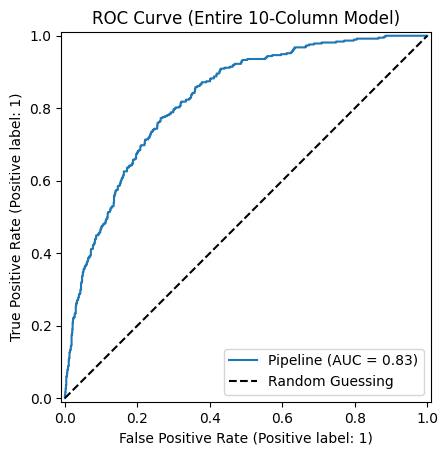

In [37]:
RocCurveDisplay.from_estimator(pipeline, X_test, y_test)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing') # Baseline diagonal line
plt.title('ROC Curve (Entire 10-Column Model)')
plt.legend()
plt.show()

In [37]:
print(classification_report(y_test, pipeline.predict(X_test)))

              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [38]:
import joblib
joblib.dump(pipeline, "../model/churn_model.pkl")

['../model/churn_model.pkl']

In [39]:
print(df["Contract"].unique())
print(df["PaymentMethod"].unique())
print(df["InternetService"].unique())

<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str
<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str


In [31]:
print(df["Churn"].value_counts())

Churn
No     5163
Yes    1869
Name: count, dtype: int64
